# Egyptian Real Estate Listings Analysis

This Jupyter Notebook is dedicated to analyzing real estate listings in Egypt. The dataset for this project is taken from [Kaggle](https://www.kaggle.com/datasets/hassankhaled21/egyptian-real-estate-listings) and generated using real data from PropertyFinder Egypt.

In this analysis, I'll focus on finding insights related to real estate prices in Egypt, such as the features that correlate with price and the regions that have underpriced properties. 

## Part 1: Importing the Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import prettytable
prettytable.DEFAULT='DEFAULT'
%load_ext sql
%matplotlib inline

In [2]:
path = "/kaggle/input/datasets/hassankhaled21/egyptian-real-estate-listings/egypt_real_estate_listings.csv"
df = pd.read_csv(path)
df.head()

,url,price,description,location,type,size,bedrooms,bathrooms,available_from,payment_method,down_payment
0,https://www.propertyfinder.eg/en/plp/buy/chale...,"8,000,000",OWN A CHALET IN EL GOUNA WITH A PRIME LOCATION...,"Swan Lake Gouna, Al Gouna, Hurghada, Red Sea",Chalet,732 sqft / 68 sqm,1+ Maid,1,31 Aug 2025,Cash,"1,200,000 EGP"
1,https://www.propertyfinder.eg/en/plp/buy/villa...,"25,000,000","For sale, a villa with immediate delivery in C...","Karmell, New Zayed City, Sheikh Zayed City, Giza",Villa,"2,368 sqft / 220 sqm",4,4,2 Sep 2025,Cash,"2,100,000 EGP"
2,https://www.propertyfinder.eg/en/plp/buy/chale...,"15,135,000","With a down payment of EGP 1,513,000, a fully ...","Azha North, Ras Al Hekma, North Coast",Chalet,"1,270 sqft / 118 sqm",2,2,19 Aug 2025,Cash,"1,513,000 EGP"
3,https://www.propertyfinder.eg/en/plp/buy/apart...,"12,652,000",Own an apartment in New Cairo with a minimal d...,"Taj City, 5th Settlement Compounds, The 5th Se...",Apartment,"1,787 sqft / 166 sqm",3,2,26 Aug 2025,Installments,"1,260,000 EGP"
4,https://www.propertyfinder.eg/en/plp/buy/villa...,"45,250,000",Project: Granville\nLocation: Fifth Settlement...,"Granville, New Capital City, Cairo",Villa,"4,306 sqft / 400 sqm",7,7,2 Sep 2025,Cash,"2,262,500 EGP"


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19924 entries, 0 to 19923
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   url             19924 non-null  object
 1   price           19385 non-null  object
 2   description     19846 non-null  object
 3   location        19833 non-null  object
 4   type            19847 non-null  object
 5   size            19847 non-null  object
 6   bedrooms        19780 non-null  object
 7   bathrooms       19784 non-null  object
 8   available_from  19261 non-null  object
 9   payment_method  19383 non-null  object
 10  down_payment    5445 non-null   object
dtypes: object(11)
memory usage: 1.7+ MB


As we can see, the data in this table is unprocessed and requires cleaning. This will be the next step of our analytics process.

*Note: All prices in this dataset are given in Egyptian Pounds (EGP).*

## Part 2: Data Cleaning

In [4]:
df = df.drop_duplicates()

In [5]:
df[['price', 'down_payment']] = df[['price', 'down_payment']].replace(',', '', regex=True)
df['down_payment'] = df['down_payment'].replace(' EGP', '', regex=True)
df[['price', 'down_payment']] = df[['price', 'down_payment']].replace(np.nan, 0, regex=True)
df[['price', 'down_payment']] = df[['price', 'down_payment']].astype('int64')

In [6]:
df['available_from'] = pd.to_datetime(df['available_from'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19924 entries, 0 to 19923
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   url             19924 non-null  object        
 1   price           19924 non-null  int64         
 2   description     19846 non-null  object        
 3   location        19833 non-null  object        
 4   type            19847 non-null  object        
 5   size            19847 non-null  object        
 6   bedrooms        19780 non-null  object        
 7   bathrooms       19784 non-null  object        
 8   available_from  19261 non-null  datetime64[ns]
 9   payment_method  19383 non-null  object        
 10  down_payment    19924 non-null  int64         
dtypes: datetime64[ns](1), int64(2), object(8)
memory usage: 1.7+ MB


In [7]:
objs = ['type', 'bedrooms', 'bathrooms', 'payment_method']
for obj in objs:
    print(df[obj].value_counts())
    print()

type
Apartment          8355
Chalet             4038
Villa              3570
Townhouse          1335
Twin House          834
Duplex              622
Penthouse           569
iVilla              268
Hotel Apartment     104
Land                 63
Cabin                38
Palace               23
Whole Building       14
Roof                  6
Full Floor            4
Bulk Sale Unit        3
Bungalow              1
Name: count, dtype: int64

bedrooms
3               4959
3+ Maid         3737
2               2849
4+ Maid         2126
2+ Maid         1748
4               1126
5+ Maid          786
1                751
1+ Maid          447
5                325
studio           280
6+ Maid          254
7+ Maid          128
6                 93
7++ Maid          67
studio+ Maid      48
7                 33
7+                23
Name: count, dtype: int64

bathrooms
3       6562
2       5529
4       3281
1       2097
5       1313
6        463
7        223
7+       159
2.0       48
3.0       48
1.0   

In [8]:
df['bathrooms'] = df['bathrooms'].str.replace(r'\.0|\+', '', regex=True).replace('none', '0')
df['bathrooms'] = df['bathrooms'].fillna('0')
df['bathrooms'].value_counts()

bathrooms
3    6610
2    5577
4    3300
1    2118
5    1324
6     466
7     384
0     145
Name: count, dtype: int64

In [9]:
df['has_maid'] = df['bedrooms'].str.contains('Maid', case=False)
df['bedrooms'] = df['bedrooms'].str.replace(r"\+ Maid|\++ Maid|\+", '', regex=True).replace('studio', '0')
df['bedrooms'] = df['bedrooms'].fillna('0')
df['bedrooms'].value_counts()

bedrooms
3    8696
2    4597
4    3252
1    1198
5    1111
0     472
6     347
7     251
Name: count, dtype: int64

In [10]:
df['has_maid'].value_counts()

has_maid
False    10439
True      9341
Name: count, dtype: int64

In [11]:
df[['bedrooms', 'bathrooms']] = df[['bedrooms', 'bathrooms']].astype('int64')
df['size_sqm'] = df['size'].str.extract(r'(\d+)\s*sqm')
df['size_sqm'] = df['size_sqm'].astype('float64')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19924 entries, 0 to 19923
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   url             19924 non-null  object        
 1   price           19924 non-null  int64         
 2   description     19846 non-null  object        
 3   location        19833 non-null  object        
 4   type            19847 non-null  object        
 5   size            19847 non-null  object        
 6   bedrooms        19924 non-null  int64         
 7   bathrooms       19924 non-null  int64         
 8   available_from  19261 non-null  datetime64[ns]
 9   payment_method  19383 non-null  object        
 10  down_payment    19924 non-null  int64         
 11  has_maid        19780 non-null  object        
 12  size_sqm        19847 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(4), object(7)
memory usage: 2.0+ MB


In [12]:
df['price_per_sqm'] = df['price'] / df['size_sqm']
df.head()

,url,price,description,location,type,size,bedrooms,bathrooms,available_from,payment_method,down_payment,has_maid,size_sqm,price_per_sqm
0,https://www.propertyfinder.eg/en/plp/buy/chale...,8000000,OWN A CHALET IN EL GOUNA WITH A PRIME LOCATION...,"Swan Lake Gouna, Al Gouna, Hurghada, Red Sea",Chalet,732 sqft / 68 sqm,1,1,2025-08-31,Cash,1200000,True,68.0,117647.058824
1,https://www.propertyfinder.eg/en/plp/buy/villa...,25000000,"For sale, a villa with immediate delivery in C...","Karmell, New Zayed City, Sheikh Zayed City, Giza",Villa,"2,368 sqft / 220 sqm",4,4,2025-09-02,Cash,2100000,False,220.0,113636.363636
2,https://www.propertyfinder.eg/en/plp/buy/chale...,15135000,"With a down payment of EGP 1,513,000, a fully ...","Azha North, Ras Al Hekma, North Coast",Chalet,"1,270 sqft / 118 sqm",2,2,2025-08-19,Cash,1513000,False,118.0,128262.711864
3,https://www.propertyfinder.eg/en/plp/buy/apart...,12652000,Own an apartment in New Cairo with a minimal d...,"Taj City, 5th Settlement Compounds, The 5th Se...",Apartment,"1,787 sqft / 166 sqm",3,2,2025-08-26,Installments,1260000,False,166.0,76216.867470
4,https://www.propertyfinder.eg/en/plp/buy/villa...,45250000,Project: Granville\nLocation: Fifth Settlement...,"Granville, New Capital City, Cairo",Villa,"4,306 sqft / 400 sqm",7,7,2025-09-02,Cash,2262500,False,400.0,113125.000000


In [13]:
df[['description', 'location']] = df[['description', 'location']].fillna('None')
df['has_maid'] = df['has_maid'].fillna(False)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19924 entries, 0 to 19923
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   url             19924 non-null  object        
 1   price           19924 non-null  int64         
 2   description     19924 non-null  object        
 3   location        19924 non-null  object        
 4   type            19847 non-null  object        
 5   size            19847 non-null  object        
 6   bedrooms        19924 non-null  int64         
 7   bathrooms       19924 non-null  int64         
 8   available_from  19261 non-null  datetime64[ns]
 9   payment_method  19383 non-null  object        
 10  down_payment    19924 non-null  int64         
 11  has_maid        19924 non-null  bool          
 12  size_sqm        19847 non-null  float64       
 13  price_per_sqm   19843 non-null  float64       
dtypes: bool(1), datetime64[ns](1), float64(2), int64(4), o

/tmp/ipykernel_17/1010672425.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['has_maid'] = df['has_maid'].fillna(False)


## Part 3: Exploratory Data Analysis

In this EDA, I'll try to answer the following questions with the given data:
- What is the average housing price in various regions of Egypt?
- How does the housing price vary based on the payment method, size, number of bathrooms and bedrooms, housing type, and maid presence?
- What factors positively correlate with the housing price in Egypt?
- What regions have a disproportionately high or low price per square meter ratio?
- How do the real estate listings' prices vary based on their date of availability?

In [14]:
df.describe()

,price,bedrooms,bathrooms,available_from,down_payment,size_sqm,price_per_sqm
count,1.992400e+04,19924.000000,19924.000000,19261,1.992400e+04,19847.000000,1.984300e+04
mean,1.597123e+07,2.955330,2.931439,2025-08-21 09:40:40.807850240,5.413960e+05,204.362120,inf
min,0.000000e+00,0.000000,0.000000,2023-06-14 00:00:00,0.000000e+00,0.000000,0.000000e+00
25%,5.700000e+06,2.000000,2.000000,2025-08-19 00:00:00,0.000000e+00,126.000000,3.763441e+04
50%,1.000000e+07,3.000000,3.000000,2025-08-31 00:00:00,0.000000e+00,170.000000,6.265823e+04
75%,1.800000e+07,3.000000,4.000000,2025-09-01 00:00:00,1.000000e+05,240.000000,9.647045e+04
max,8.400000e+08,7.000000,7.000000,2027-10-31 00:00:00,1.500000e+08,985.000000,inf
std,2.352638e+07,1.194616,1.310086,NaN,2.206562e+06,128.150337,NaN


In [15]:
print(f"The mean housing price in Egypt equals {df['price'].mean():,.2f}")
print(f"The median housing price in Egypt equals {df['price'].median():,.2f}")

The mean housing price in Egypt equals 15,971,226.79
The median housing price in Egypt equals 10,000,000.00


<Axes: xlabel='price', ylabel='Density'>

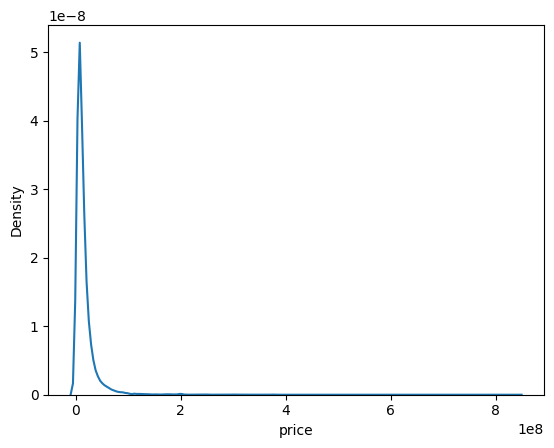

In [16]:
sns.kdeplot(x='price', data=df)

As we can see, most real estate listings have a median price of around 10 million EGP. The fact that the mean is higher than the median by almost 6 million EGP suggests that the dataset contains significant outliers.

We will now extract the regions from the locations column to gain insights into the distributions of prices based on regions in Egypt.

In [17]:
df['location'] = df['location'].str.strip()
df['region'] = df['location'].str.rsplit(",", n=1).str[-1].str.strip()
df.head()

,url,price,description,location,type,size,bedrooms,bathrooms,available_from,payment_method,down_payment,has_maid,size_sqm,price_per_sqm,region
0,https://www.propertyfinder.eg/en/plp/buy/chale...,8000000,OWN A CHALET IN EL GOUNA WITH A PRIME LOCATION...,"Swan Lake Gouna, Al Gouna, Hurghada, Red Sea",Chalet,732 sqft / 68 sqm,1,1,2025-08-31,Cash,1200000,True,68.0,117647.058824,Red Sea
1,https://www.propertyfinder.eg/en/plp/buy/villa...,25000000,"For sale, a villa with immediate delivery in C...","Karmell, New Zayed City, Sheikh Zayed City, Giza",Villa,"2,368 sqft / 220 sqm",4,4,2025-09-02,Cash,2100000,False,220.0,113636.363636,Giza
2,https://www.propertyfinder.eg/en/plp/buy/chale...,15135000,"With a down payment of EGP 1,513,000, a fully ...","Azha North, Ras Al Hekma, North Coast",Chalet,"1,270 sqft / 118 sqm",2,2,2025-08-19,Cash,1513000,False,118.0,128262.711864,North Coast
3,https://www.propertyfinder.eg/en/plp/buy/apart...,12652000,Own an apartment in New Cairo with a minimal d...,"Taj City, 5th Settlement Compounds, The 5th Se...",Apartment,"1,787 sqft / 166 sqm",3,2,2025-08-26,Installments,1260000,False,166.0,76216.867470,Cairo
4,https://www.propertyfinder.eg/en/plp/buy/villa...,45250000,Project: Granville\nLocation: Fifth Settlement...,"Granville, New Capital City, Cairo",Villa,"4,306 sqft / 400 sqm",7,7,2025-09-02,Cash,2262500,False,400.0,113125.000000,Cairo


In [18]:
print(df['region'].value_counts())

region
Cairo             7610
North Coast       5246
Giza              4276
Red Sea           1598
Suez               601
Alexandria         385
None                91
Qalyubia            58
South Sainai        28
Al Daqahlya         11
Matrouh              6
Sharqia              4
Asyut                4
Demyat               3
Aswan                1
Luxor                1
Kafr El Sheikh       1
Name: count, dtype: int64


Now that we have the information about the regions present in this dataset, we can move on to price calculations.

To do this efficiently, though, we should transfer the dataset into a local SQL database.

In [19]:
con = sqlite3.connect('egypt_real_estate.db')
%sql sqlite:///egypt_real_estate.db
df.to_sql('real_estate', con, if_exists='replace', index=False)

19924

In [20]:
query = """
SELECT
    region,
    avg(price) as avg_price
FROM
    real_estate
WHERE
    region != "None"
GROUP BY
    region
ORDER BY
    avg_price desc
"""
insight = pd.read_sql_query(query, con)
insight

,region,avg_price
0,North Coast,2.150627e+07
1,Cairo,1.629089e+07
2,Red Sea,1.384708e+07
3,Giza,1.202968e+07
4,Alexandria,7.862521e+06
5,Suez,7.096947e+06
6,Qalyubia,5.981410e+06
7,Kafr El Sheikh,5.000000e+06
8,Demyat,4.306667e+06
9,South Sainai,3.909466e+06


Text(0.5, 1.0, 'Average Price in Regions of Egypt')

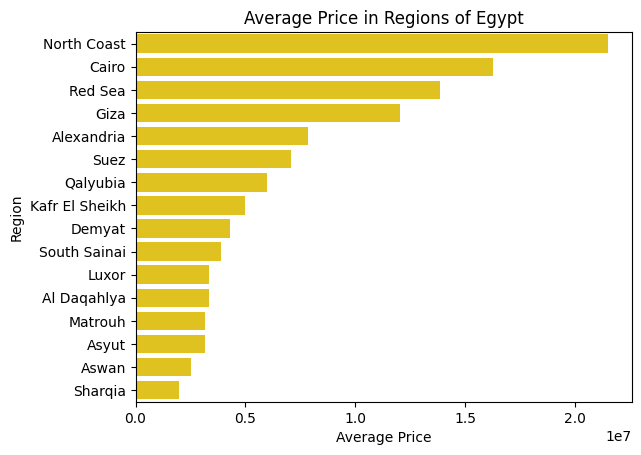

In [21]:
sns.barplot(x='avg_price', y='region', data=insight, color='gold')
plt.xlabel('Average Price')
plt.ylabel('Region')
plt.title('Average Price in Regions of Egypt')

- In this bar chart, we can see that the real estate in the regions of Giza, Red Sea, Cairo, and the North Coast tend to have a much higher average selling price than other regions of Egypt.
- This is likely because these regions have a high tourist presence, which naturally keeps the demand for real estate high.

Text(0.5, 1.0, 'Variation of Real Estate Prices by Payment Method')

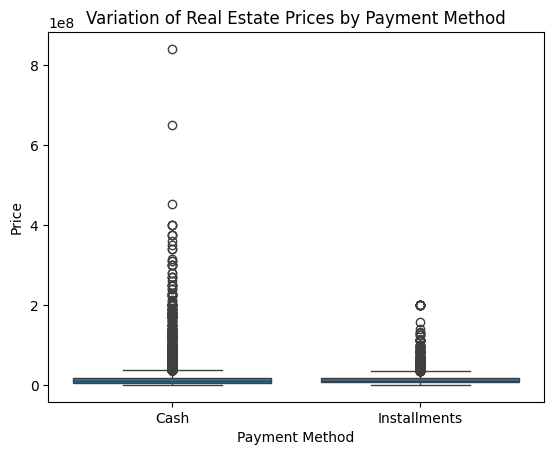

In [22]:
sns.boxplot(x='payment_method', y='price', data=df)
plt.xlabel('Payment Method')
plt.ylabel('Price')
plt.title("Variation of Real Estate Prices by Payment Method")

- We can observe that, in most cases, the average price of real estate objects in Egypt tends to be roughly equal regardless of the payment method.
- However, real estate objects with the payment method of cash are more likely to be priced disproportionately higher than average.

Text(0.5, 1.0, 'Relationship Between Real Estate Price and Size in Egypt')

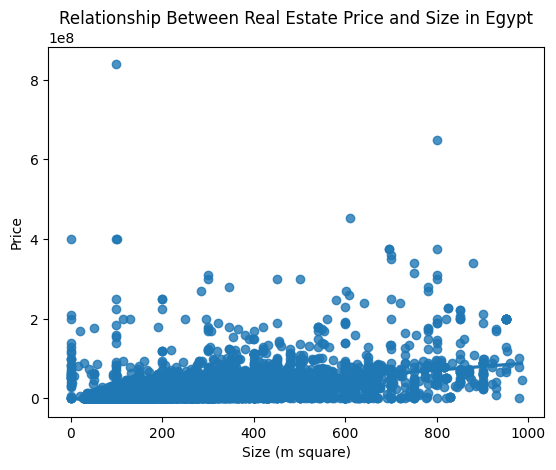

In [23]:
sns.regplot(x='size_sqm', y='price', data=df)
plt.xlabel('Size (m square)')
plt.ylabel('Price')
plt.title('Relationship Between Real Estate Price and Size in Egypt')

Based on what we can see in this graph, there is a slight positive correlation between size and price, but it is not strong.

Additionally, there are many outlier real estate objects present in the data, where the price is high regardless of the size of the listed real estate object.

Text(0.5, 1.0, 'Correlation Between Real Estate Price and Number of Bathrooms and Bedrooms')

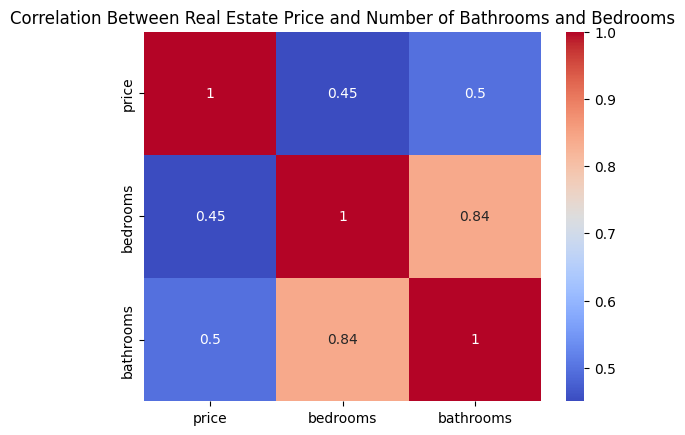

In [24]:
insight = df[['price', 'bedrooms', 'bathrooms']]
sns.heatmap(insight.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Between Real Estate Price and Number of Bathrooms and Bedrooms')

Just as expected, we can see that there is a moderate correlation between the number of bathrooms and bedrooms and the real estate price.

It is also notable that there is a strong correlation between bedrooms and bathrooms, which means that the higher the number of bedrooms, the higher the number of bathrooms there will likely be.

In [25]:
query = """
SELECT
    type,
    avg(price) as avg_price
FROM
    real_estate
WHERE
    type != 'None'
GROUP BY
    type
ORDER BY
    avg_price DESC
"""
insight = pd.read_sql_query(query, con)

Text(0.5, 1.0, 'Average Real Estate Price by Type')

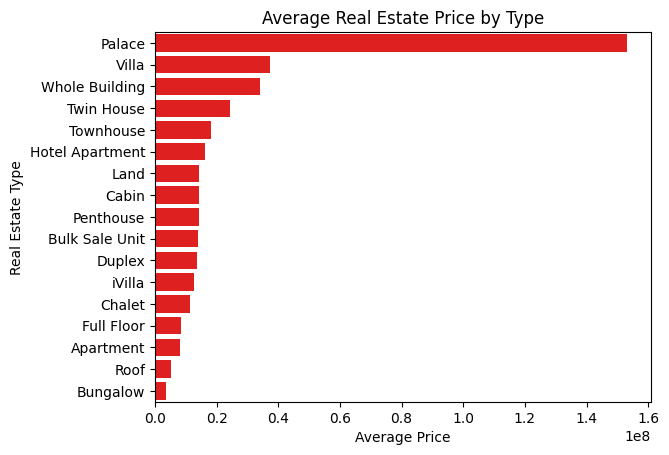

In [26]:
sns.barplot(x='avg_price', y='type', data=insight, color='red')
plt.xlabel('Average Price')
plt.ylabel('Real Estate Type')
plt.title('Average Real Estate Price by Type')

We can extract multiple insights by looking at this graph:
- Palaces tend to be disproportionately higher than other real estate objects in price. This is unsurprising given their size and features.
- The cheapest real estate objects on average are bungalows.
- Based on this graph, just as shown in the calculations above, the mean price seems to be around 15-16 million EGP.

Text(0.5, 1.0, 'Variation of Real Estate Prices by Maid Presence')

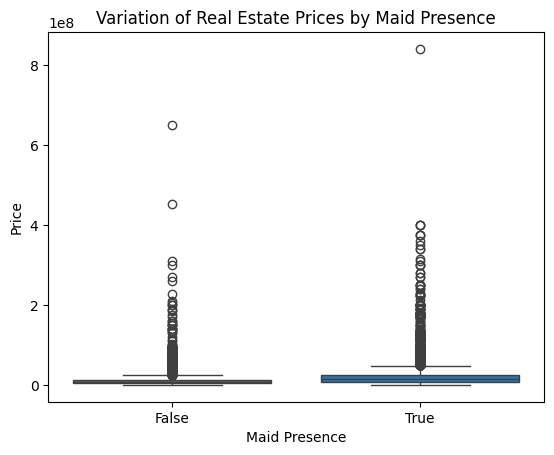

In [27]:
sns.boxplot(x='has_maid', y='price', data=df)
plt.xlabel('Maid Presence')
plt.ylabel('Price')
plt.title("Variation of Real Estate Prices by Maid Presence")

As we can see, real estate listings that include maids have higher average selling prices and are more likely to be priced higher than the market average.

In [28]:
avg_price_per_sqm = df['price_per_sqm'].mean()
median_price_per_sqm = df['price_per_sqm'].median()
print(f"The average price per square meter is {avg_price_per_sqm}")
print(f"The median price per square meter is {median_price_per_sqm}")

The average price per square meter is inf
The median price per square meter is 62658.22784810127


Based on the values we've observed, the mean price per square meter should be lower. This suggests that there are outliers present in the data.

We will now create a box plot to visualize them.

<Axes: xlabel='price_per_sqm'>

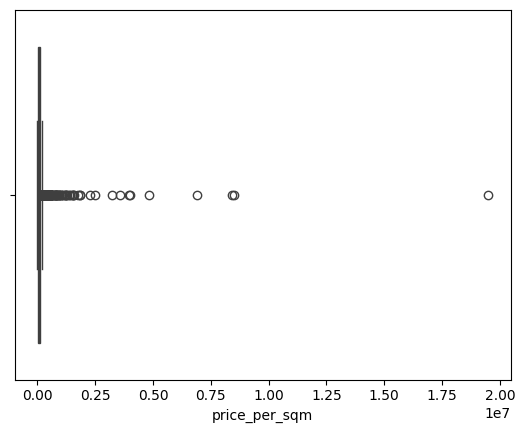

In [29]:
sns.boxplot(x='price_per_sqm', data=df)

As we can see in this boxplot, although there are many outliers in the dataset, some have disproportionately high ratios of almost 20 million EGP per square meter.

This can create problems when creating the bar chart for future analysis. To deal with this issue, we'll first query the SQLite database to list those outliers, then delete them from the table for convenient visualization.

In [30]:
%%sql
SELECT
    price,
    location,
    region
    type,
    size_sqm,
    price_per_sqm
FROM real_estate
WHERE price_per_sqm > 18000000

 * sqlite:///egypt_real_estate.db
Done.


price,location,type,size_sqm,price_per_sqm
39000000,"Madinaty, Cairo",Cairo,2.0,19500000.0
79000000,"North Bay, Al Gouna, Hurghada, Red Sea",Red Sea,0.0,inf
120000000,"Seazen, Qesm Ad Dabaah, North Coast",North Coast,0.0,inf
65000000,"Palm Hills Kattameya, El Katameya Compounds, El Katameya, New Cairo City, Cairo",Cairo,0.0,inf
52000000,"Hacienda Bay, Sidi Abdel Rahman, North Coast",North Coast,0.0,inf
72000000,"Katameya Dunes, El Katameya Compounds, El Katameya, New Cairo City, Cairo",Cairo,0.0,inf
115000000,"Lake View, 5th Settlement Compounds, The 5th Settlement, New Cairo City, Cairo",Cairo,0.0,inf
138000000,"Swan Lake Katameya, The 1st Settlement, New Cairo City, Cairo",Cairo,0.0,inf
28000000,"Touristic Zone 1, Touristic Zone, Al Motamayez District, 6 October City, Giza",Giza,0.0,inf
60000000,"Les Rois, 5th Settlement Compounds, The 5th Settlement, New Cairo City, Cairo",Cairo,0.0,inf


Some listings from Cairo, Giza, and a couple of other regions offer no data about the property size. To maintain the accuracy of our analysis, we will remove those outliers from the database.

In [31]:
%%sql
DELETE FROM real_estate
WHERE price_per_sqm > 18000000

 * sqlite:///egypt_real_estate.db
32 rows affected.


[]

In [32]:
query = """
SELECT
    region,
    round(avg(price_per_sqm), 2) as avg_price_per_sqm
FROM
    real_estate
WHERE
    region != 'None'
GROUP BY
    region
HAVING
    avg_price_per_sqm IS NOT NULL
ORDER BY
    avg_price_per_sqm desc
"""
insight = pd.read_sql_query(query, con)

Text(0.5, 1.0, 'Average Price per Square Meter in Regions of Egypt')

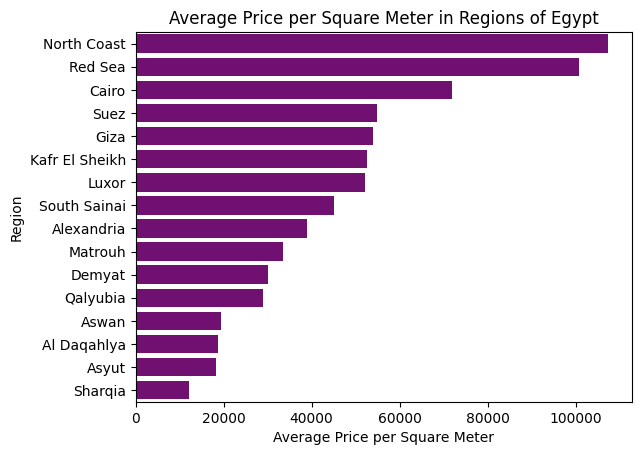

In [33]:
sns.barplot(x='avg_price_per_sqm', y='region', data=insight, color='purple')
plt.xlabel('Average Price per Square Meter')
plt.ylabel('Region')
plt.title('Average Price per Square Meter in Regions of Egypt')

In [34]:
%%sql
SELECT
    avg(price_per_sqm)
FROM
    real_estate
WHERE region != 'North Coast' and region!= 'Red Sea' and region!='Cairo'

 * sqlite:///egypt_real_estate.db
Done.


avg(price_per_sqm)
52302.70195030763


- The graph and the calculation above show that real estate listings in Cairo, the Red Sea, and the North Coast regions have much higher rates of price per square meter than the average.
- Excluding those outliers from our calculations, we find that the mean ratio is equal to 52302.7 EGP per square meter.
- It is also worth noting that real estate listings in Sharqia, Asyut, Al Daqahlya, and Aswan have relatively low prices per square meter.
    - This suggests that these regions could be underdeveloped in terms of infrastructure, healthcare, education, or employment opportunities, and thus, the real estate listings there are low in demand.
    - The government can gather more data on these regions to determine the regions' problems and invest in their development.

Text(0.5, 1.0, "Variation of Real Estate Listings' Prices by Availability Date")

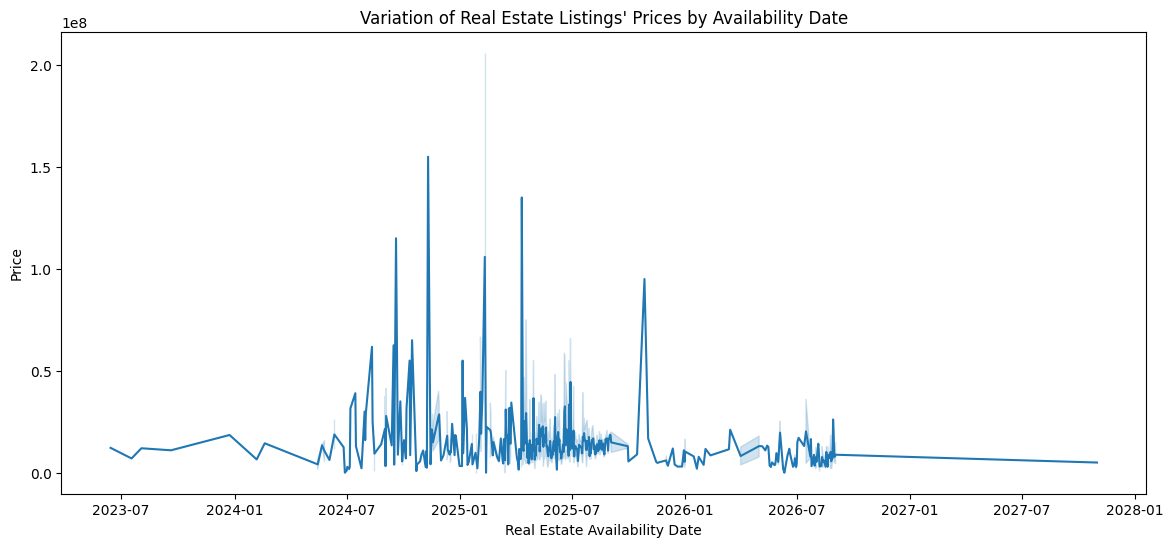

In [35]:
fig = plt.figure(figsize=(14,6))
sns.lineplot(x='available_from', y='price', data=df)
plt.xlabel('Real Estate Availability Date')
plt.ylabel('Price')
plt.title("Variation of Real Estate Listings' Prices by Availability Date")

- There seems to be no meaningful relationship between real estate price and the listings' availability date.
- However, from July 2014 to July 2015, the real estate prices fluctuated heavily with multiple visible outliers.
    - This is likely because Egypt experienced political tensions and economic challenges in this period, as well as a fire at the Ramses Exchange in Cairo on July 7 2024, causing market uncertainty.
    - However, this is just a hypothesis. To identify the true reasons for the fluctuation, more research needs to be conducted.

## Conclusion & Insights

**Here is a summary of our EDA findings:**
- The median price of real estate in Egypt is 10 million EGP.
    - The mean price, on the other hand, is around 16 million EGP.
- Real estate listings in the North Coast, Giza, Cairo, and the Red Sea have higher-than-average real estate prices.
    - Additionally, North Coast, Cairo, and the Red Sea have higher-than-average price-per-square-meter ratios.
    - The median price-per-square-meter ratio in Egypt is 62658 EGP per square meter.
    - Real estate listings in Sharqia, Asyut, Al Daqahlya, and Aswan are undervalued relative to the median and mean, which suggests that these regions are underdeveloped and require government investment.
- Real estate assets bought with cash are more likely to be priced higher than average than the assets paid for by card.
- As expected, there is a medium correlation between the real estate listings' price and their size, number of bedrooms, and bathrooms.
- The five most expensive real estate types in Egypt are palaces, villas, whole buildings, twin houses, and townhouses.
    - Palaces are, on average, magnitudes more expensive than other real estate types.
- Real estate listings with maids have a higher average price than those without them.
- There is no meaningful relationship between the listing availability date and real estate price, although there is a period of heavy fluctuation between July 2024 and July 2025.
    - More research needs to be conducted to identify the reasons for this fluctuation.

### Actionable Insights

- The government can increase investment in the development of the regions of Sharqia, Asyut, Al Daqahlya, and Aswan.
    - This is because the analysis suggests that the real estate in these regions is lower in demand than average, which suggests that there are issues that decrease local quality of life.
    - The government can conduct surveys and interviews with the local population to identify the root causes and address them.
- Businesses and real estate firms can focus on Cairo, the Red Sea, and the North Coast to make profitable sales.
    - To increase the likelihood of successful sales, the sellers should hire maids, make sure that the real estate assets have 3 or more bedrooms and bathrooms, and set cash as the primary payment type.
    - Realistically, the sellers can focus on whole buildings, twin houses, and townhouses, as they are high in demand and aren't too expensive to repurchase or construct.
- If one wants to purchase quality real estate in Egypt and is not concerned with living in luxurious regions, they can search for listings in Suez, Qalyubia, and Kafr El Sheikh.
    - These regions contain real estate assets at a fair price and have adequate living conditions.
    - The final choice, however, should always depend on one's individual needs, preferences, and constraints.